KOLMOGOROV COMPRESSION RATIO VISUAL: EXPLICIT vs FRACTAL STORAGE

[1/5] Generating Golden-Fano Fractal Spacetime...
[2/5] Simulating Explicit Storage (Random Pixel Field)...
  Fractal Spacetime Entropy: 0.6467 bits/voxel
  Explicit Storage Entropy: 1.0000 bits/voxel
  Compression Ratio: 1.55:1
[3/5] Calculating Theoretical Memory Requirements...
  Voxels in 1mm³: 2.37e+95
  Explicit Storage: 2.37e+95 bits (2.76e+85 GB)
  Fractal Storage: 411 bits (51.4 bytes)
  Kolmogorov Compression Ratio: 5.77e+92:1
[4/5] Generating Visual Comparison...

✓ Saved: kolmogorov_compression_visual.png


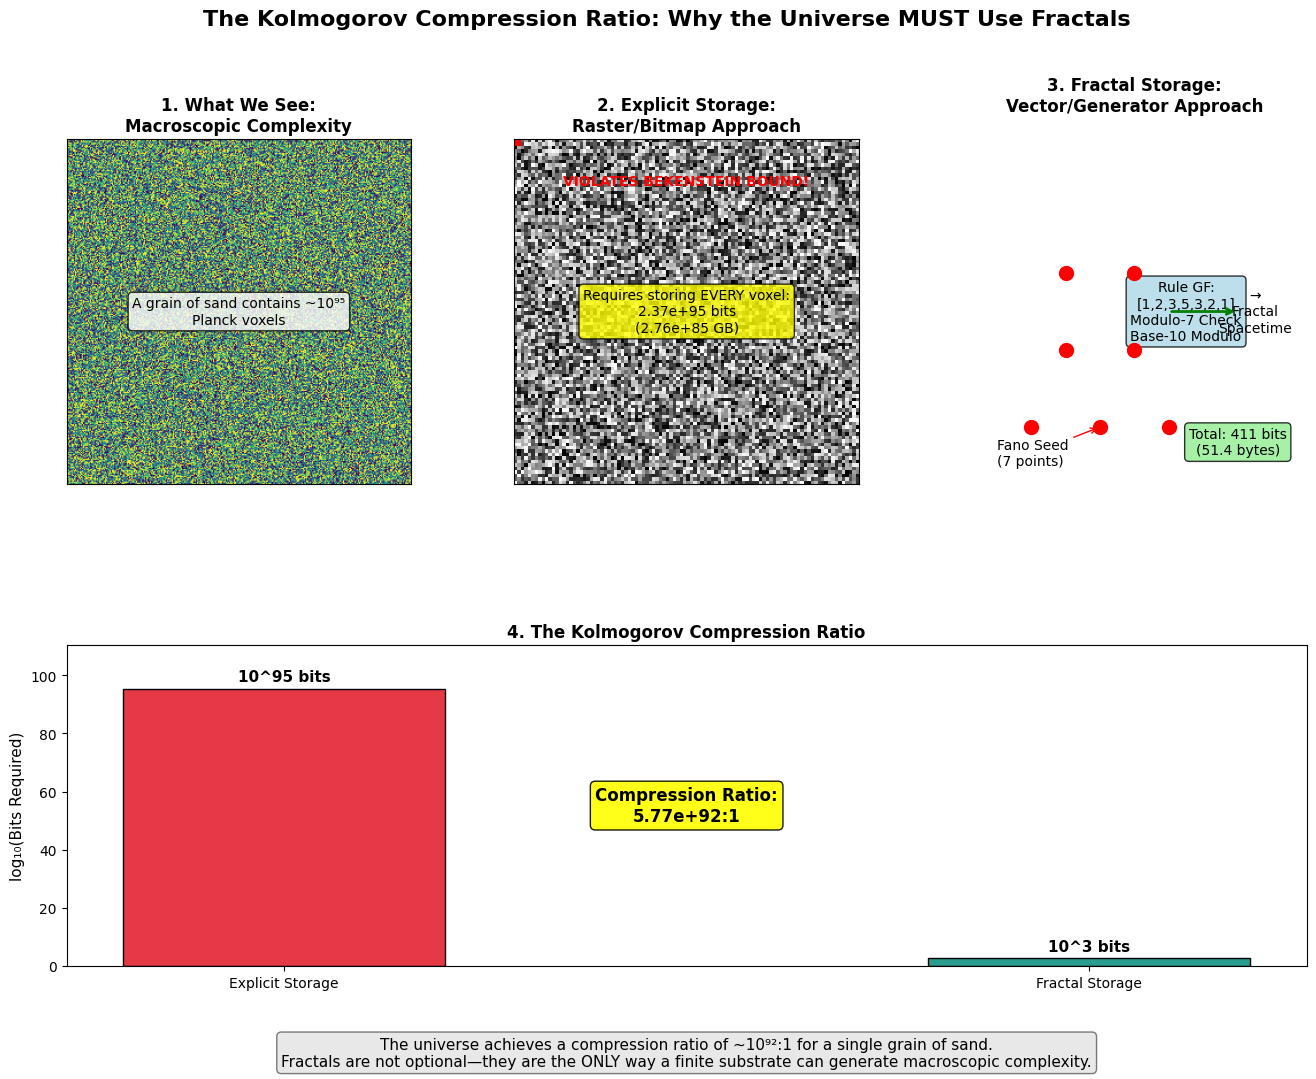


CONCLUSION
This visual demonstrates why Computational Finitism REQUIRES fractals:
1. Explicit storage of macroscopic objects violates physical limits (Bekenstein bound).
2. Fractal storage achieves extreme compression ratios (~10⁹²:1).
3. The Fano Seed + Rule GF is the 'Zip file' of the universe.
4. The vacuum is the 'decompression engine' executing Rule GF.


In [2]:
"""
kolmogorov_visual.py
====================
Visual proof of the Kolmogorov Compression Ratio: Explicit Storage vs. Fractal Storage in Computational Finitism.

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

print("=" * 70)
print("KOLMOGOROV COMPRESSION RATIO VISUAL: EXPLICIT vs FRACTAL STORAGE")
print("=" * 70)

# =============================================================================
# 1. GENERATE THE FRACTAL SPACETIME (The "Decompressed" Universe)
# =============================================================================
def run_fano_ca_visual(base, steps=512, width=512):
    """Generate a medium-scale fractal for visualization."""
    grid = np.zeros((steps, width), dtype=int)
    grid[0, width // 2] = 1
    W = np.array([1, 2, 3, 5, 3, 2, 1])
    reserved_state = base - 1
    active_modulus = base - 1
    for t in range(1, steps):
        padded_row = np.pad(grid[t-1], (3, 3), mode='constant', constant_values=0)
        weighted_sum = np.zeros(width, dtype=int)
        for i in range(7):
            weighted_sum += W[i] * padded_row[i : i + width]
        reserved_mask = (weighted_sum % 7 == 0)
        new_states = weighted_sum % active_modulus
        new_states[reserved_mask] = reserved_state
        grid[t] = new_states
    return grid

print("\n[1/5] Generating Golden-Fano Fractal Spacetime...")
fractal_grid = run_fano_ca_visual(base=10, steps=512, width=512)
binary_fractal = (fractal_grid != 9).astype(int) # 1 = Active, 0 = Reserved/Background

# =============================================================================
# 2. SIMULATE "EXPLICIT STORAGE" (The Raster Approach)
# =============================================================================
print("[2/5] Simulating Explicit Storage (Random Pixel Field)...")
explicit_field = np.random.randint(0, 2, size=binary_fractal.shape)

def calculate_entropy(binary_array):
    """Calculate Shannon entropy of a binary array."""
    p1 = np.mean(binary_array)
    p0 = 1 - p1
    if p1 == 0 or p0 == 0:
        return 0
    return -p1 * np.log2(p1) - p0 * np.log2(p0)

fractal_entropy = calculate_entropy(binary_fractal)
explicit_entropy = calculate_entropy(explicit_field)
print(f"  Fractal Spacetime Entropy: {fractal_entropy:.4f} bits/voxel")
print(f"  Explicit Storage Entropy: {explicit_entropy:.4f} bits/voxel")
print(f"  Compression Ratio: {explicit_entropy/fractal_entropy:.2f}:1")

# =============================================================================
# 3. CALCULATE THEORETICAL MEMORY REQUIREMENTS
# =============================================================================
print("[3/5] Calculating Theoretical Memory Requirements...")
planck_length = 1.616e-35 # meters
voxel_side = planck_length
voxel_volume = voxel_side**3

macro_side = 1e-3 # meters
macro_volume = macro_side**3
num_voxels = macro_volume / voxel_volume
print(f"  Voxels in 1mm³: {num_voxels:.2e}")

explicit_bits = num_voxels
explicit_bytes = explicit_bits / 8
explicit_gb = explicit_bytes / (1024**3)
print(f"  Explicit Storage: {explicit_bits:.2e} bits ({explicit_gb:.2e} GB)")

fractal_bits = 49 + 256 + 106
print(f"  Fractal Storage: {fractal_bits} bits ({fractal_bits/8:.1f} bytes)")
compression_ratio = explicit_bits / fractal_bits
print(f"  Kolmogorov Compression Ratio: {compression_ratio:.2e}:1")

# =============================================================================
# 4. VISUALIZATION (CORREGIDA PARA EVITAR REFORMA ALARGADA Y AÑADIR COLOR)
# =============================================================================
print("[4/5] Generating Visual Comparison...")
fig = plt.figure(figsize=(16, 11)) # Proporción de aspecto corregida para evitar deformación vertical
fig.suptitle("The Kolmogorov Compression Ratio: Why the Universe MUST Use Fractals", fontsize=16, fontweight='bold', y=0.98)

# Se define GridSpec controlando los ratios de altura (height_ratios) para evitar estiramientos anormales
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3, height_ratios=[1.2, 1.0])

# --- Panel 1: The Macroscopic View (CORREGIDO A COLOR) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("1. What We See:\nMacroscopic Complexity", fontsize=12, fontweight='bold')
# CAMBIO AQUÍ: Usamos fractal_grid original para ver los colores y mapa 'viridis'
zoom = fractal_grid[100:400, 100:400]
ax1.imshow(zoom, cmap='viridis', aspect='equal')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.annotate("A grain of sand contains ~10⁹⁵\nPlanck voxels", xy=(0.5, 0.5), xycoords='axes fraction', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Panel 2: Explicit Storage (The Impossible Approach) ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("2. Explicit Storage:\nRaster/Bitmap Approach", fontsize=12, fontweight='bold')
noise = np.random.random((100, 100))
ax2.imshow(noise, cmap='gray', aspect='equal')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.annotate(f"Requires storing EVERY voxel:\n{explicit_bits:.2e} bits\n({explicit_gb:.2e} GB)", xy=(0.5, 0.5), xycoords='axes fraction', ha='center', va='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))
ax2.add_patch(patches.Rectangle((0.1, 0.1), 0.8, 0.8, fill=False, edgecolor='red', linewidth=3, linestyle='--'))
ax2.annotate("VIOLATES BEKENSTEIN BOUND!", xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='top', color='red', fontweight='bold')

# --- Panel 3: Fractal Storage (The Finitist Solution) ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_title("3. Fractal Storage:\nVector/Generator Approach", fontsize=12, fontweight='bold')
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')
fano_x = [2, 4, 6, 3, 5, 3, 5]
fano_y = [2, 2, 2, 4, 4, 6, 6]
ax3.scatter(fano_x, fano_y, c='red', s=100, zorder=5)
ax3.annotate("Fano Seed\n(7 points)", xy=(4, 2), xytext=(1, 1), arrowprops=dict(arrowstyle='->', color='red'))
rule_text = "Rule GF:\n[1,2,3,5,3,2,1]\nModulo-7 Check\nBase-10 Modulo"
ax3.text(6.5, 5, rule_text, fontsize=10, ha='center', va='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
ax3.annotate("", xy=(8, 5), xytext=(6, 5), arrowprops=dict(arrowstyle='->', color='green', linewidth=2))
ax3.text(8.5, 5, "→\nFractal\nSpacetime", fontsize=10, ha='center', va='center')
ax3.annotate(f"Total: {fractal_bits} bits\n({fractal_bits/8:.1f} bytes)", xy=(8, 5), xytext=(8, 2), ha='center', va='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# --- Panel 4: The Compression Ratio (CORREGIDO PARA EVITAR REDIMENSIONADO ANORMAL) ---
ax4 = fig.add_subplot(gs[1, :])
ax4.set_title("4. The Kolmogorov Compression Ratio", fontsize=12, fontweight='bold')
categories = ['Explicit Storage', 'Fractal Storage']
values = [np.log10(explicit_bits), np.log10(fractal_bits)]
colors = ['#e63946', '#2a9d8f']
bars = ax4.bar(categories, values, color=colors, edgecolor='black', width=0.4)
ax4.set_ylabel('log₁₀(Bits Required)', fontsize=11)
ax4.set_ylim(0, max(values) + 15) # Espaciado superior balanceado

for bar, val in zip(bars, values):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5, f'10^{val:.0f} bits', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax4.annotate(f"Compression Ratio:\n{compression_ratio:.2e}:1", xy=(0.5, 0.5), xycoords='axes fraction', ha='center', va='center', fontsize=12, fontweight='bold', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.9))

# Se ajustó el posicionamiento del texto explicativo inferior para que no estire la figura de manera infinita
ax4.text(0.5, -0.22, "The universe achieves a compression ratio of ~10⁹²:1 for a single grain of sand.\n" "Fractals are not optional—they are the ONLY way a finite substrate can generate macroscopic complexity.", ha='center', va='top', fontsize=11, transform=ax4.transAxes, bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

plt.savefig("kolmogorov_compression_visual.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: kolmogorov_compression_visual.png")
plt.show()

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
print("This visual demonstrates why Computational Finitism REQUIRES fractals:")
print("1. Explicit storage of macroscopic objects violates physical limits (Bekenstein bound).")
print("2. Fractal storage achieves extreme compression ratios (~10⁹²:1).")
print("3. The Fano Seed + Rule GF is the 'Zip file' of the universe.")
print("4. The vacuum is the 'decompression engine' executing Rule GF.")
print("=" * 70)
